In [17]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import joblib
import shap

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
def _threshold_proximity(amount: float, thresholds: list, decay_rate: float = 0.05) -> float:
    """
    Continuous 0-100 score for how close `amount` sits just BELOW the
    nearest threshold in `thresholds` (thresholds it did not cross).
 
    Uses smooth exponential decay instead of a hardcoded band, so there's
    no arbitrary cutoff deciding "close enough" — an amount ₹1 under a
    threshold scores near 100, an amount far below any threshold decays
    smoothly toward 0, and amounts exceeding every threshold score 0.
    Works identically for ANY number/value of thresholds — a ₹10L limit
    is caught the same way as a ₹2L one, with no separate hardcoded band.
    """
    candidates = [t for t in thresholds if amount <= t]
    if not candidates:
        return 0.0
    nearest = min(candidates)
    gap_fraction = (nearest - amount) / nearest
    return round(100 * np.exp(-gap_fraction / decay_rate), 2)

In [20]:
# Feature Engineering
def engineer_features(
    df: pd.DataFrame,
    mp_budget_lookup: dict,
    approval_thresholds: list = None,
) -> pd.DataFrame:
    """
    Builds the engineered feature vector from raw transaction rows.
 
    df columns expected (raw): MP Name, Constituency, IDA, Vendor,
        Expenditure Amount (₹), Expenditure Date, Payment Status
    mp_budget_lookup: {mp_name: total_allocation_in_rupees}
    approval_thresholds: list of rupee amounts that trigger extra
        administrative/tender scrutiny in the relevant state/IDA's
        procurement rules
    """
    if approval_thresholds is None:
        approval_thresholds = [50000, 500000, 5000000]
 
    df = df.copy()
    df["Expenditure Date"] = (
        df["Expenditure Date"].astype(str).str.strip().replace("", pd.NA)
    )
    df['Expenditure Date'] = pd.to_datetime(df['Expenditure Date'], format='%d-%b-%Y', errors='coerce').dt.tz_localize(None)
    n_before = len(df)
    df = df.dropna(subset=["Expenditure Date"])
    if len(df) < n_before:
        print(f"WARNING: dropped {n_before - len(df)} row(s) with unparseable 'Expenditure Date' values.")
    df = df.sort_values("Expenditure Date")
 
    # --- expenditure_amount ---
    df["expenditure_amount"] = df["Fund Disbursed Amount ( ₹ )"].str.replace(',','').astype(float)
 
    # --- threshold_proximity_pct ---
    # Replaces the old binary is_threshold_smurf band. Continuous score:
    # how close THIS SINGLE transaction sits just under any known
    # approval threshold, regardless of which threshold or how far under.
    df["threshold_proximity_pct"] = df["expenditure_amount"].apply(
        lambda amt: _threshold_proximity(amt, approval_thresholds)
    )
 
    # --- vendor_payout_velocity + vendor_cumulative_30d ---
    # Computed together: velocity = count of payouts to the same
    # (MP, Vendor) pair in the trailing 30 days; cumulative = sum of
    # those payouts' amounts over the same window (used below to catch
    # invoice splitting, where no single payment crosses a threshold but
    # the running total to one vendor does).
    df["vendor_payout_velocity"] = 0
    df["vendor_cumulative_30d"] = 0.0
    for (mp, vendor), group in df.groupby(["MP Name", "Vendor Name"]):
        idx = group.index
        dates = group["Expenditure Date"].values
        amounts = group["expenditure_amount"].values
        counts, sums = [], []
        for i, d in enumerate(dates):
            window_start = d - np.timedelta64(90, "D")
            in_window = (dates > window_start) & (dates <= d)
            counts.append(np.sum(in_window))
            sums.append(amounts[in_window].sum())
        df.loc[idx, "vendor_payout_velocity"] = counts
        df.loc[idx, "vendor_cumulative_30d"] = sums
 
    # --- cumulative_vendor_spend_vs_threshold_pct ---
    # The actual invoice-splitting signature: the RUNNING TOTAL paid to
    # one vendor may sit just under a threshold even though it took
    # several small payments to get there, none of which individually
    # looked suspicious. Same continuous scoring as threshold_proximity_pct,
    # applied to the cumulative sum instead of a single transaction.
    df["cumulative_vendor_spend_vs_threshold_pct"] = df["vendor_cumulative_30d"].apply(
        lambda amt: _threshold_proximity(amt, approval_thresholds)
    )
 
    # --- amount_to_mp_budget_pct ---
    df["mp_total_allocation"] = df["MP Name"].map(mp_budget_lookup)
    df["amount_to_mp_budget_pct"] = (
        df["expenditure_amount"] / df["mp_total_allocation"] * 100
    )
 
    # --- ida_monthly_txns ---
    df["year_month"] = df["Expenditure Date"].dt.to_period("M")
    ida_monthly_counts = df.groupby(["IDA", "year_month"])["IDA"].transform("count")
    df["ida_monthly_txns"] = ida_monthly_counts
 
    feature_cols = [
        "expenditure_amount",
        "threshold_proximity_pct",
        "vendor_payout_velocity",
        "cumulative_vendor_spend_vs_threshold_pct",
        "amount_to_mp_budget_pct",
        "ida_monthly_txns",
    ]
    return df, feature_cols

In [21]:
# Model Training
class ExpenditureAnomalyModel:
    def __init__(self, contamination: float = 0.03, random_state: int = 42):
        # contamination = expected proportion of anomalies in the data.
        # Tune this against a labeled/audited sample if you have one;
        # 0.02-0.05 is a reasonable starting default for fraud-style problems.
        self.contamination = contamination
        self.random_state = random_state
        self.scaler = StandardScaler()
        self.model = IsolationForest(
            n_estimators=300,
            contamination=self.contamination,
            random_state=self.random_state,
            n_jobs=-1,
        )
        self.feature_cols = None
        self._score_min = None
        self._score_max = None
        self._background = None  # plain array; explainer rebuilt fresh on load
        self.explainer = None
 
    def fit(self, df: pd.DataFrame, feature_cols: list):
        self.feature_cols = feature_cols
        X = df[feature_cols].values
        X_scaled = self.scaler.fit_transform(X)
        self.model.fit(X_scaled)
 
        # Calibrate the 0-100 risk_score scale against the training
        # distribution of raw decision_function scores.
        raw_scores = self.model.decision_function(X_scaled)
        self._score_min = raw_scores.min()
        self._score_max = raw_scores.max()
 
        # --- SHAP explainer ---
        # Isolation Forest has no closed-form tree-attribution shortcut
        # (unlike gradient-boosted trees), so we explain decision_function()
        # directly using SHAP's model-agnostic Permutation explainer.
        # A background sample (not the full dataset) is used as the
        # "typical" reference point contributions are measured against.
        # NOTE: only the plain numpy array is kept for persistence — the
        # fitted shap.Explainer wraps a bound method + masker state that is
        # fragile to pickle across shap/sklearn versions (this caused the
        # IndexError after reloading). The explainer itself is rebuilt
        # fresh in fit() and in load(), never unpickled directly.
        self._background = shap.sample(X_scaled, min(100, len(X_scaled)), random_state=self.random_state)
        self._build_explainer()
        return self
    
    def _build_explainer(self):
        try:
            self.explainer = shap.TreeExplainer(self.model, feature_names=self.feature_cols)
        except Exception:
            self.explainer = shap.Explainer(
                self.model.decision_function, self._background,
                feature_names=self.feature_cols, algorithm="permutation",
            )
        
    def _to_risk_score(self, raw_score: float) -> float:
        """
        Maps raw_anomaly_score (higher = more normal, lower = more anomalous)
        onto a 0-100 risk_score where HIGHER = more risky.
        Uses min-max scaling against the training distribution, then inverts.
        """
        span = self._score_max - self._score_min
        if span == 0:
            normalized = 0.5
        else:
            normalized = (raw_score - self._score_min) / span
        normalized = np.clip(normalized, 0, 1)
        risk_score = (1 - normalized) * 100  # invert: low raw score -> high risk
        return round(float(risk_score), 1)
 
    def explain_row(self, row: pd.Series, top_n: int = None) -> list:
        """
        Returns SHAP contribution of each feature toward this row's raw
        decision_function score, sorted by magnitude (largest impact first).
 
        Convention used here: decision_function is LOWER for anomalies, so
        a NEGATIVE shap value means that feature pushed the score down
        (i.e. pushed the transaction toward "more anomalous").
        We flip the sign so positive = "increased anomaly risk", which
        matches the risk_score direction and is more intuitive to read.
        """
        X = row[self.feature_cols].values.reshape(1, -1)
        X_scaled = self.scaler.transform(X)
 
        shap_values = self.explainer(X_scaled)
        contributions = [
            {
                "feature": feat,
                "value": row[feat],
                "contribution_to_risk": round(float(-shap_val), 4),
            }
            for feat, shap_val in zip(self.feature_cols, shap_values.values[0])
        ]
        contributions.sort(key=lambda c: abs(c["contribution_to_risk"]), reverse=True)
        return contributions[:top_n] if top_n else contributions
 
    def predict_row(self, row: pd.Series, explain: bool = True, top_n_reasons: int = 3) -> dict:
        X = row[self.feature_cols].values.reshape(1, -1)
        X_scaled = self.scaler.transform(X)
 
        raw_score = float(self.model.decision_function(X_scaled)[0])
        prediction_label = int(self.model.predict(X_scaled)[0])  # -1 or 1
        risk_score = self._to_risk_score(raw_score)
 
        is_anomaly = bool(prediction_label == -1)
 
        if risk_score >= 75:
            risk_level = "CRITICAL_ANOMALY"
        elif risk_score >= 40:
            risk_level = "MEDIUM_RISK"
        else:
            risk_level = "LOW_RISK"
 
        output = {
            "Work ID": row['Work ID'],
            "risk_score": risk_score,
            "risk_level": risk_level,
            "is_anomaly": is_anomaly,
            "metrics": {
                "amount": float(row["expenditure_amount"]),
                "threshold_proximity_pct": float(row["threshold_proximity_pct"]),
                "vendor_30d_frequency": int(row["vendor_payout_velocity"]),
                "cumulative_vendor_spend_vs_threshold_pct": float(
                    row["cumulative_vendor_spend_vs_threshold_pct"]
                ),
                "budget_impact_pct": round(float(row["amount_to_mp_budget_pct"]), 2),
                "ida_monthly_txns": int(row["ida_monthly_txns"]),
            },
            "raw_anomaly_score": round(raw_score, 4),
        }
 
        if explain:
            output["top_contributing_features"] = self.explain_row(row, top_n=top_n_reasons)
 
        return output
 
    def save(self, path: str):
        joblib.dump(
            {
                "model": self.model,
                "scaler": self.scaler,
                "feature_cols": self.feature_cols,
                "score_min": self._score_min,
                "score_max": self._score_max,
                "contamination": self.contamination,
                 "background": self._background,  # plain array — safe to pickle,
            },
            path,
        )
 
    @classmethod
    def load(cls, path: str):
        state = joblib.load(path)
        obj = cls(contamination=state["contamination"])
        obj.model = state["model"]
        obj.scaler = state["scaler"]
        obj.feature_cols = state["feature_cols"]
        obj._score_min = state["score_min"]
        obj._score_max = state["score_max"]
        obj._background = state["background"]
        obj._build_explainer()
        return obj

In [22]:
# --- Load raw data ---
exp_df = pd.read_csv("New Datasets/Expenditures Lok Sabha.csv")
alloc_df=pd.read_csv("New Datasets/Allocated Limit MP Lok Sabha.csv")

mp_budget_lookup = dict(zip(alloc_df['MP Name'],alloc_df['Allocated Amount in rupees'].str.replace(',','').astype(float)))

# --- Feature engineering ---
df_features, feature_cols = engineer_features(exp_df, mp_budget_lookup)

# # --- Train ---
# engine = ExpenditureAnomalyModel(contamination=0.03)
# engine.fit(df_features, feature_cols)
# engine.save("models/expenditure_anomaly_model_new.joblib")

# # --- Load Model ---
engine=ExpenditureAnomalyModel.load('models/expenditure_anomaly_model.joblib')

In [23]:
test_df=exp_df.iloc[int(0.99 * len(exp_df)):-1]
test_df_features, test_feature_cols = engineer_features(test_df, mp_budget_lookup)

In [24]:
# --- Score every transaction (batch) ---
results = test_df_features.apply(engine.predict_row, axis=1)
test_df_features["risk_output"] = results

# --- Example: score a single new live transaction ---
new_txn = df_features.iloc[0]  # replace with a real incoming row
output = engine.predict_row(new_txn, top_n_reasons=3)
print(output)

{'Work ID': 'WS/MP347/2024-2025/138112', 'risk_score': 28.0, 'risk_level': 'LOW_RISK', 'is_anomaly': False, 'metrics': {'amount': 1254628.0, 'threshold_proximity_pct': 0.0, 'vendor_30d_frequency': 1, 'cumulative_vendor_spend_vs_threshold_pct': 0.0, 'budget_impact_pct': 0.73, 'ida_monthly_txns': 2}, 'raw_anomaly_score': 0.1476, 'top_contributing_features': [{'feature': 'expenditure_amount', 'value': np.float64(1254628.0), 'contribution_to_risk': 1.8617}, {'feature': 'amount_to_mp_budget_pct', 'value': np.float64(0.7276178733640266), 'contribution_to_risk': 1.4112}, {'feature': 'vendor_payout_velocity', 'value': np.int64(1), 'contribution_to_risk': -0.4825}]}


In [25]:
test_df_features['risk_score']=test_df_features['risk_output'].str['risk_score']
test_df_features

,Sr. No.,State,Work,Work ID,IDA,MP Name,Constituency,Expenditure Date,Vendor Name,Payment Status,...,threshold_proximity_pct,vendor_payout_velocity,vendor_cumulative_30d,cumulative_vendor_spend_vs_threshold_pct,mp_total_allocation,amount_to_mp_budget_pct,year_month,ida_monthly_txns,risk_output,risk_score
58944,58945,Kerala,"Construction of roads, link roads, pathways or...",WS/MP347/2024-2025/138112,KOLLAM(DISTRICT COLLECTOR KOLLAM_IDA),Shri Suresh Kodikunnil,MAVELIKKARA(SC),2024-09-09,SURESH KUMAR K,Payment Success,...,0.00,1,1254628.0,0.00,1.724295e+08,0.727618,2024-09,2,"{'Work ID': 'WS/MP347/2024-2025/138112', 'risk...",28.0
58533,58534,Chhattisgarh,"Construction of roads, link roads, pathways or...",WS/MP18278/2024-2025/137680,JANJGIR-CHAMPA(DISTRICT COLLECTOR JANJGIR CHAM...,KAMLESH JANGDE,JANJGIR CHAMPA(SC),2024-09-20,SARPANCH GRAM PANCHAYAT DURPA,Payment Success,...,1.83,1,400000.0,1.83,1.503844e+08,0.265985,2024-09,2,"{'Work ID': 'WS/MP18278/2024-2025/137680', 'ri...",10.4
58536,58537,Chhattisgarh,"Construction of roads, link roads, pathways or...",WS/MP18278/2024-2025/137679,JANJGIR-CHAMPA(DISTRICT COLLECTOR JANJGIR CHAM...,KAMLESH JANGDE,JANJGIR CHAMPA(SC),2024-09-20,SARPANCH GRAM PANCHAYAT SONIYATATH,Payment Success,...,1.83,1,400000.0,1.83,1.503844e+08,0.265985,2024-09,2,"{'Work ID': 'WS/MP18278/2024-2025/137679', 'ri...",10.4
58781,58782,Kerala,Construction of buildings for community cultur...,WS/MP345/2024-2025/134145,KOLLAM(DISTRICT COLLECTOR KOLLAM_IDA),Shri NK Premachandran,KOLLAM,2024-09-28,PRADEEP KUMAR P,Payment Success,...,0.00,1,96867.0,0.00,1.714780e+08,0.056489,2024-09,2,"{'Work ID': 'WS/MP345/2024-2025/134145', 'risk...",3.3
58510,58511,Chhattisgarh,"Construction of roads, link roads, pathways or...",WS/MP18278/2024-2025/134667,SAKTI(COLLECTOR SAKTI_IDA),KAMLESH JANGDE,JANJGIR CHAMPA(SC),2024-09-30,GRAM PANCHAYAT MASANIYAKALA,Payment Success,...,44.93,1,480000.0,44.93,1.503844e+08,0.319182,2024-09,2,"{'Work ID': 'WS/MP18278/2024-2025/134667', 'ri...",51.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58542,58543,Maharashtra,Construction of flood control embankments/ pro...,WS/MP18128/2026-2027/214175,PALGHAR(DISTRICT COLLECTOR PALGHAR_IDA),DR. HEMANT VISHNU SAVARA,PALGHAR(ST),2026-08-13,CHETAN RAJENDRA DHANMEHER,Payment Success,...,0.00,1,988204.0,0.00,1.470000e+08,0.672248,2026-08,1,"{'Work ID': 'WS/MP18128/2026-2027/214175', 'ri...",21.6
58946,58947,Kerala,"Construction of roads, link roads, pathways or...",WS/MP345/2024-2025/176680,KOLLAM(DISTRICT COLLECTOR KOLLAM_IDA),Shri NK Premachandran,KOLLAM,2026-08-17,SURESH KUMAR K,Payment Success,...,1.89,3,1125730.0,0.00,1.714780e+08,0.233720,2026-08,2,"{'Work ID': 'WS/MP345/2024-2025/176680', 'risk...",7.0
58947,58948,Kerala,"Construction of roads, link roads, pathways or...",WS/MP345/2025-2026/186352,KOLLAM(DISTRICT COLLECTOR KOLLAM_IDA),Shri NK Premachandran,KOLLAM,2026-08-17,SURESH KUMAR K,Payment Success,...,1.69,3,1125730.0,0.00,1.714780e+08,0.232111,2026-08,2,"{'Work ID': 'WS/MP345/2025-2026/186352', 'risk...",6.7
58458,58459,Odisha,"Construction of roads, link roads, pathways or...",WS/MP18146/2025-2026/173995,MAYURBHANJ(DISTRICT COLLECTOR MAYURBHANJ_IDA),ANANTA NAYAK,KEONJHAR(ST),2026-08-18,SUNARAM MURMU,Payment Success,...,0.00,1,200000.0,0.00,1.470000e+08,0.136054,2026-08,1,"{'Work ID': 'WS/MP18146/2025-2026/173995', 'ri...",3.5


<Axes: xlabel='Work ID', ylabel='risk_score'>

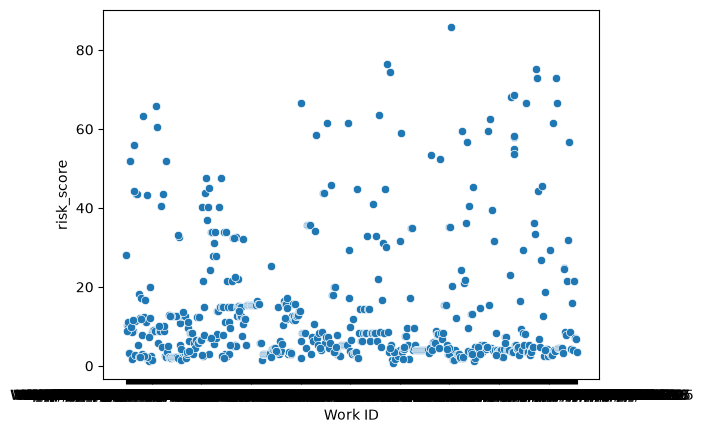

In [26]:
sns.scatterplot(data=test_df_features,x='Work ID',y='risk_score')

In [27]:
test_df_features.to_csv("New Datasets/Tested expenditure data.csv")

In [28]:
print(alloc_df['Allocated Amount in rupees'].value_counts(normalize=True).head())  # what % sit at the modal value?
print(df_features[['expenditure_amount', 'amount_to_mp_budget_pct']].corr())    # actual correlation

Allocated Amount in rupees
147000000    0.710866
171500000    0.007366
98000000     0.003683
269500000    0.003683
190289442    0.001842
Name: proportion, dtype: float64
                         expenditure_amount  amount_to_mp_budget_pct
expenditure_amount                 1.000000                 0.992251
amount_to_mp_budget_pct            0.992251                 1.000000
